In [14]:
JUPYTER_NAME = "3-lens-simulation-tuning-before-decoupling"

In [36]:
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as constants
from qiskit import transpile
from qiskit.circuit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Operator, Statevector, partial_trace
from qiskit_aer import AerSimulator
from qiskit_aer_encore.simulator import generate_aer_simulator
from qiskit_hamiltonian_simulation.time_independent.direct import (
    MomentumDomainEvolutionQuadratic,
    PositionDomainEvolutionQuadratic,
)
from qiskit_hamiltonian_simulation.time_independent.sample_based import (
    KineticEvolutionSampleBased,
    PotentialEvolutionSampleBased,
)
from qiskit_phase_propagator.sample_based_manual import (
    phase_propagate_state_with_arbitrary_signal,
)

# from qiskit_phase_propagator.sample_based import (
#     QuadraticSignalSampleBasedPhasePropagator,
# )
from qiskit_signals.helper_types import EncodingType
from qiskit_signals.quantum_axis import (
    AngularWavenumberAxis,
    MomentumAxis,
    PositionAxis,
)
from qiskit_signals.quantum_signal import GenericQuantumSignal, QuadraticQuantumSignal
from qiskit_signals.sample_based_signal import ArbitrarySignalForSampleBasedProtocol
from wave_optics_propagation.analytics import (
    free_space_propagated_gaussian_wavefront,
    gaussian_signal,
    propagated_gaussian_wavefront_hitting_lens,
)
from wave_optics_propagation.big_matrix_version import big_matrix_circ
from wave_optics_propagation.elements import (
    free_space_signal_generator,
    radius_of_convex_planar_lens_as_a_func_of_z,
    thin_lens_signal_generator,
    thin_transparent_plate_signal_generator,
)
from wave_optics_propagation.storage import (
    save_initial_parameters,
    save_numpy_results,
)
from wave_optics_propagation.visualization import plot_wavefunction

In [37]:
experiment_datetime = datetime.now()

---


### Initial parameters


In [38]:
# beam parameters
vacuum_wavelength = 1e-6  # 1 micron
beam_FWHM = 5e-3  # 5 mm

# lens parameters
focal_length = 200e-3  # 200 mm
lens_diameter = 25e-3  # 25 mm
refractive_index = 1.5

# free space propagation parameters
propagation_after_lens = 1.5 * focal_length

# simulation parameters
transverse_length = 100e-3  # 100 mm, transverse simulation window
num_of_steps_after_lens = 10
lens_slices = 100
num_qubits = 6
max_delta = 0.01

### Constants


In [39]:
c = constants.c
# hbar = constants.hbar

### Derived parameters


In [40]:
# geometry
radius_of_curvature = focal_length * (refractive_index - 1)
lens_radius = lens_diameter / 2
lens_thickness = radius_of_curvature - np.sqrt(radius_of_curvature**2 - lens_radius**2)


k_0 = 2 * constants.pi / vacuum_wavelength
reduced_wavelength = vacuum_wavelength / refractive_index

dimension = 2**num_qubits
delta_x = transverse_length / dimension

gaussian_mean = transverse_length / 2
gaussian_beam_waist = beam_FWHM / np.sqrt(2 * np.log(2))
# gaussian_sigma = gaussian_beam_waist / np.sqrt(2)

# vacuum_rayleigh_length = (np.pi * gaussian_beam_waist**2) / vacuum_wavelength

lens_slice_thickness = lens_thickness / lens_slices
step_size_after_lens = propagation_after_lens / num_of_steps_after_lens

### Derived objects


In [41]:
lens_slice_positions = (
    np.linspace(0, lens_thickness, lens_slices, endpoint=False)
    + lens_slice_thickness / 2
)  # choosing the midpoint in each transverse slice

lens_transverse_radii = [
    radius_of_convex_planar_lens_as_a_func_of_z(radius_of_curvature, z, lens_thickness)
    for z in lens_slice_positions
]
print(lens_thickness)
print(lens_slice_positions)
print(lens_transverse_radii)

0.0007843258350778426
[3.92162918e-06 1.17648875e-05 1.96081459e-05 2.74514042e-05
 3.52946626e-05 4.31379209e-05 5.09811793e-05 5.88244376e-05
 6.66676960e-05 7.45109543e-05 8.23542127e-05 9.01974710e-05
 9.80407294e-05 1.05883988e-04 1.13727246e-04 1.21570504e-04
 1.29413763e-04 1.37257021e-04 1.45100279e-04 1.52943538e-04
 1.60786796e-04 1.68630055e-04 1.76473313e-04 1.84316571e-04
 1.92159830e-04 2.00003088e-04 2.07846346e-04 2.15689605e-04
 2.23532863e-04 2.31376121e-04 2.39219380e-04 2.47062638e-04
 2.54905896e-04 2.62749155e-04 2.70592413e-04 2.78435671e-04
 2.86278930e-04 2.94122188e-04 3.01965447e-04 3.09808705e-04
 3.17651963e-04 3.25495222e-04 3.33338480e-04 3.41181738e-04
 3.49024997e-04 3.56868255e-04 3.64711513e-04 3.72554772e-04
 3.80398030e-04 3.88241288e-04 3.96084547e-04 4.03927805e-04
 4.11771063e-04 4.19614322e-04 4.27457580e-04 4.35300838e-04
 4.43144097e-04 4.50987355e-04 4.58830614e-04 4.66673872e-04
 4.74517130e-04 4.82360389e-04 4.90203647e-04 4.98046905e-04
 5

### Approximations checks


In [42]:
assert (
    gaussian_beam_waist > 10 * vacuum_wavelength
)  # ensure paraxial approximation validity

### Axes


In [43]:
x_axis = PositionAxis(
    num_qubits=num_qubits, delta_x=delta_x, encoding=EncodingType.UNSIGNED
)
k_axis = AngularWavenumberAxis.from_position_axis(x_axis)
# p_axis = MomentumAxis.from_position_axis(x_axis, hbar=hbar)

### Initial beam profile


0.004246609001440096 0.005 0.05


(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

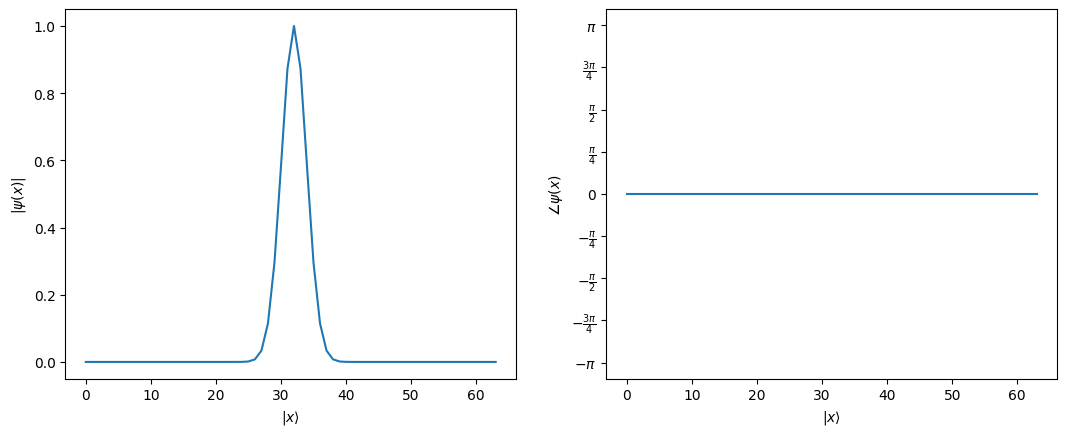

In [44]:
# def psi_signal_function(x):
#     norm_factor = 1 / (gaussian_sigma * (2 * constants.pi) ** 0.25)
#     return norm_factor * np.exp(-(((x - gaussian_mean) / gaussian_beam_waist) ** 2))


# def psi_signal_function(x):
#     return np.where(
#         (x > 1 / 3) & (x < 2 / 3),
#         1,
#         0,
#     )


# def psi_signal_function(x):
#     signal = np.zeros(dimension)
#     middle = dimension // 2
#     signal[middle - 20 : middle - 15] = 1
#     signal[middle + 15 : middle + 20] = 1
#     return signal

# psi_flat = Statevector.from_label("+" * num_qubits)

# psi = GenericQuantumSignal(x_axis, psi_signal_function)

psi = gaussian_signal(x_axis, gaussian_beam_waist, gaussian_mean)

# print(np.linalg.norm(psi.data) ** 2)
print(gaussian_beam_waist, beam_FWHM, gaussian_mean)
plot_wavefunction(psi.data, normalize=False)

### Lens potentials


In [45]:
lens_signals = [
    thin_transparent_plate_signal_generator(
        x_axis=x_axis,
        refractive_index=refractive_index,
        thickness=lens_slice_thickness,
        radius=lens_radius,
        wavelength=vacuum_wavelength,
        scale_down=True,
    )
    for lens_radius in lens_transverse_radii
]

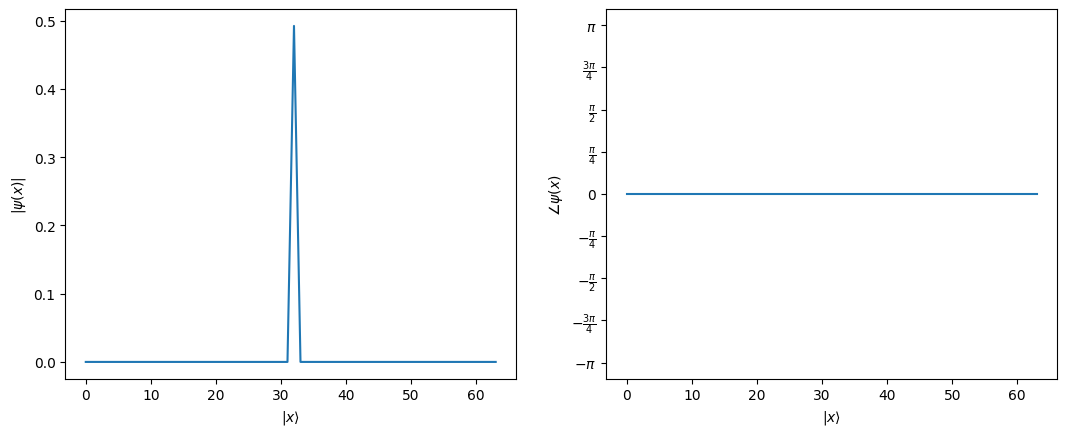

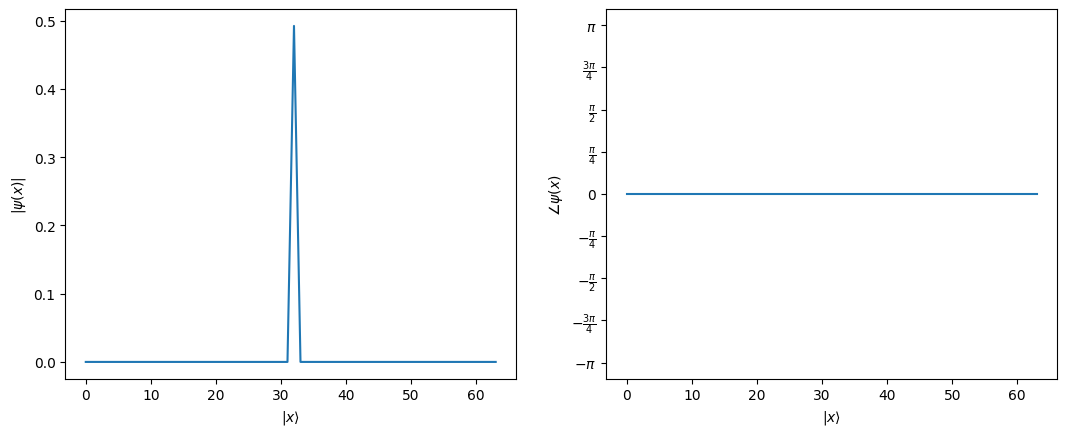

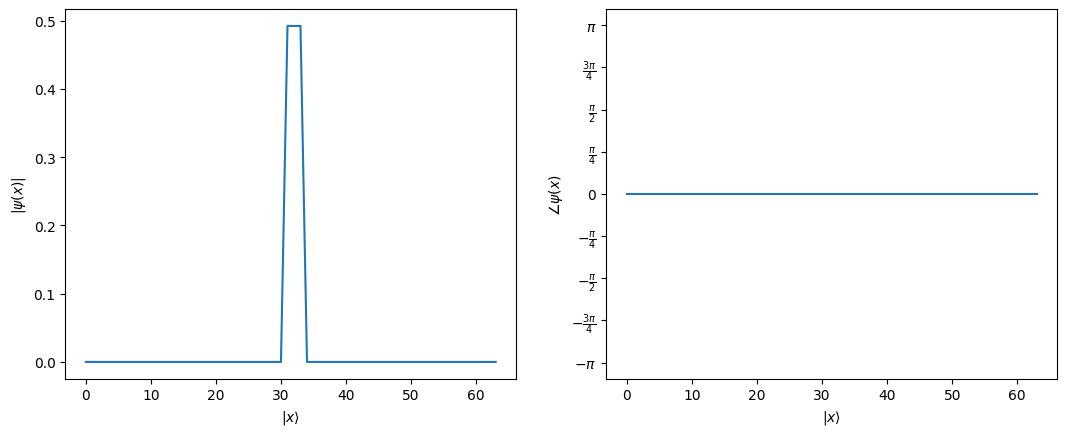

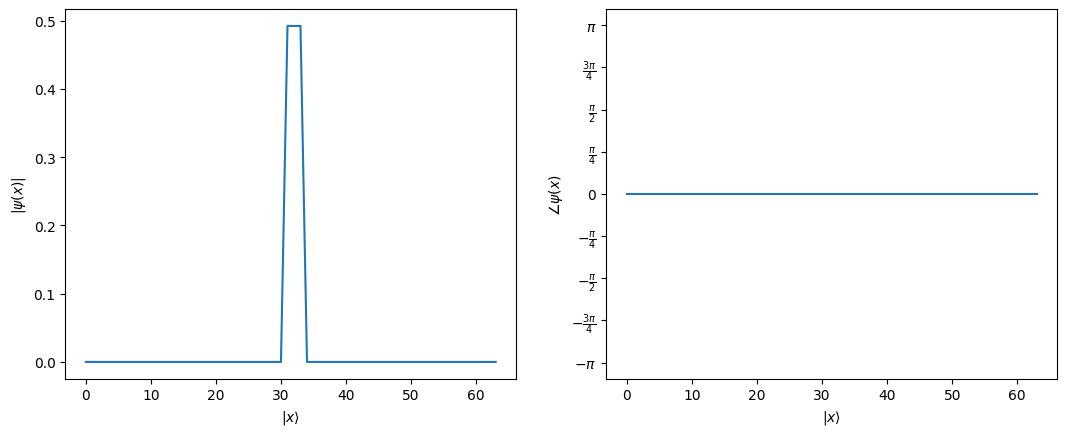

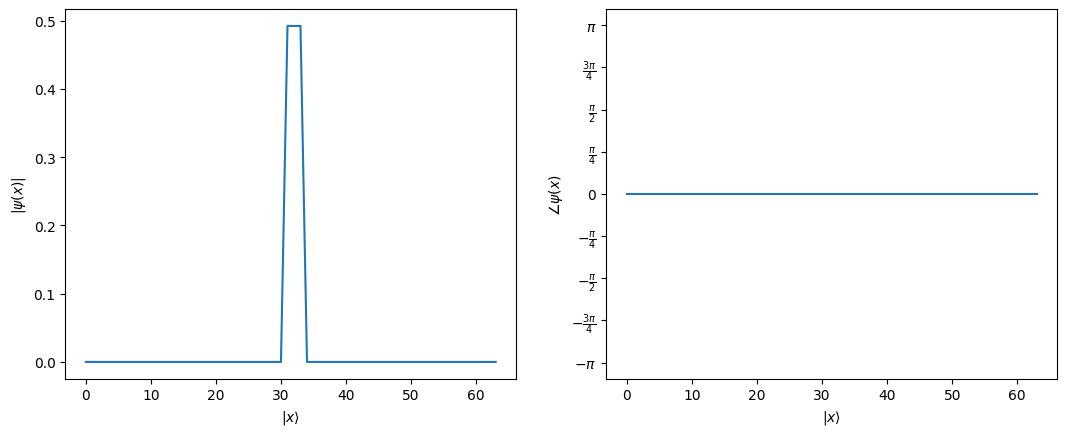

In [46]:
NUM_OF_PROFILES_TO_PLOT = 5

for i in range(NUM_OF_PROFILES_TO_PLOT):
    plot_wavefunction(lens_signals[i].data, normalize=False)

(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

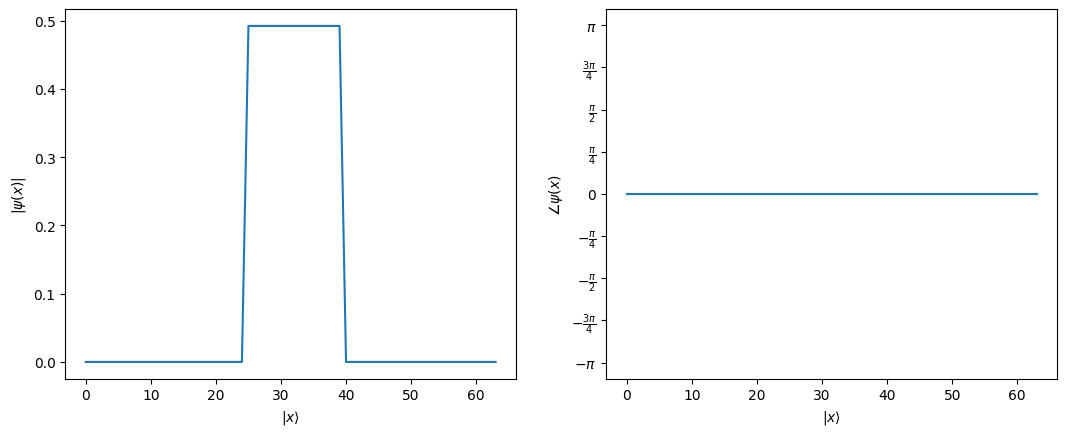

In [47]:
plot_wavefunction(lens_signals[-1].data, normalize=False)

(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

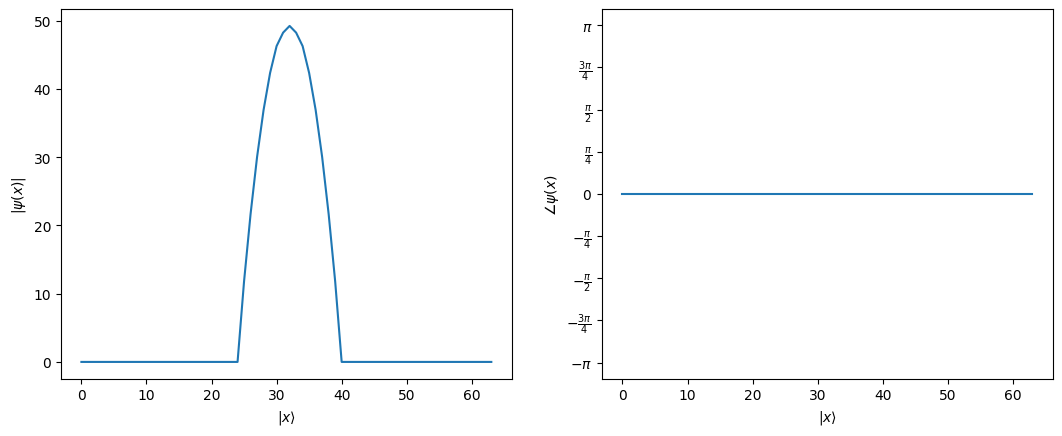

In [48]:
sum_signal = np.zeros_like(lens_signals[0].data)
for signal in lens_signals:
    sum_signal += signal.data

plot_wavefunction(sum_signal, normalize=False)

---


In [28]:
current_state = Statevector(psi.data / np.linalg.norm(psi.data))
snapshots = dict([])

snapshots[f"step_{0}"] = current_state

inside_lens_propagation_remained = lens_thickness
total_lenses_simulated = 0
### Lens
for i, lens_radius in enumerate(lens_transverse_radii):
    print(f"Doing lens slice {i + 1}/{lens_slices}")

    lens_signal = lens_signals[i]
    sample_based_lens_signal = (
        ArbitrarySignalForSampleBasedProtocol.from_generic_signal(lens_signal)
    )

    if not np.isclose(np.std(sample_based_lens_signal.data), 0):
        print(f"max value in signal: {np.max(np.abs(sample_based_lens_signal.data))}")
        print(
            f"sum of amplitude square: {np.sum(np.abs(sample_based_lens_signal.data) ** 2)}"
        )
        # continue
        current_state = phase_propagate_state_with_arbitrary_signal(
            current_state, sample_based_lens_signal, max_delta
        )
        total_lenses_simulated += 1

    else:
        print("Skipped the lens slice because it is a flat phase.")
        break

    propagator_signal = free_space_signal_generator(
        k_axis=k_axis,
        delta_t=lens_slice_thickness / c,
        wavelength=vacuum_wavelength,
        c=constants.c,
    )
    propagator = MomentumDomainEvolutionQuadratic(quadratic_signal=propagator_signal)

    current_state = current_state.evolve(propagator)
    inside_lens_propagation_remained -= lens_slice_thickness

    snapshots[f"step_lens_{i}"] = current_state

# remaining propagation once the lens slice grows larger than the simulation window
while inside_lens_propagation_remained > 0:
    propagator_signal = free_space_signal_generator(
        k_axis=k_axis,
        delta_t=inside_lens_propagation_remained / c,
        wavelength=reduced_wavelength,
        c=constants.c,
    )
    propagator = MomentumDomainEvolutionQuadratic(quadratic_signal=propagator_signal)

    current_state = current_state.evolve(propagator)
    inside_lens_propagation_remained -= inside_lens_propagation_remained

snapshots["after_lens"] = current_state

for i in range(num_of_steps_after_lens):
    print(f"Doing free space step {i + 1}/{num_of_steps_after_lens}")

    propagator_signal = free_space_signal_generator(
        k_axis=k_axis,
        delta_t=step_size_after_lens / c,
        wavelength=vacuum_wavelength,
        c=constants.c,
    )
    propagator = MomentumDomainEvolutionQuadratic(quadratic_signal=propagator_signal)

    current_state = current_state.evolve(propagator)
    snapshots[f"step_after_lens_{i + 1}"] = current_state

snapshots["final"] = current_state

Doing lens slice 1/100
max value in signal: 6.241846772423003
sum of amplitude square: 38.960651130407456
Doing lens slice 2/100
max value in signal: 6.241846772423003
sum of amplitude square: 38.960651130407456
Doing lens slice 3/100
max value in signal: 6.241846772423003
sum of amplitude square: 116.88195339122237
Doing lens slice 4/100
max value in signal: 6.241846772423003
sum of amplitude square: 116.88195339122237
Doing lens slice 5/100
max value in signal: 6.241846772423003
sum of amplitude square: 116.88195339122237
Doing lens slice 6/100
max value in signal: 6.241846772423003
sum of amplitude square: 116.88195339122237
Doing lens slice 7/100
max value in signal: 6.241846772423003
sum of amplitude square: 194.80325565203728
Doing lens slice 8/100
max value in signal: 6.241846772423003
sum of amplitude square: 194.80325565203728
Doing lens slice 9/100
max value in signal: 6.241846772423003
sum of amplitude square: 194.80325565203728
Doing lens slice 10/100
max value in signal: 6

In [29]:
save_numpy_results(snapshots, experiment_datetime, wrapper_folder=JUPYTER_NAME)
initial_parameters = {
    "timestamp": experiment_datetime.isoformat(),
    "vacuum_wavelength": vacuum_wavelength,
    "beam_FWHM": beam_FWHM,
    "focal_length": focal_length,
    "lens_diameter": lens_diameter,
    "refractive_index": refractive_index,
    "lens_thickness": lens_thickness,
    "propagation_after_lens": propagation_after_lens,
    "transverse_length": transverse_length,
    "num_of_steps_after_lens": num_of_steps_after_lens,
    "lens_slices": lens_slices,
    "num_qubits": num_qubits,
    "max_delta": max_delta,
    "total_lenses_simulated": total_lenses_simulated,
}
save_initial_parameters(
    initial_parameters, experiment_datetime, wrapper_folder=JUPYTER_NAME
)

In [30]:
data = snapshots

In [31]:
# def process_statevector(statevector):
#     return statevector
def process_statevector(statevector):
    """Process the statevector to extract position probabilities."""
    # n = statevector.num_qubits
    # rho = partial_trace(statevector, np.arange(int(n // 2), n).tolist())
    # reduced_state = rho.to_statevector()

    # return reduced_state
    return statevector


initial_statevector = process_statevector(data[f"step_{0}"])

lens_statevectors = [
    process_statevector(data[f"step_lens_{i}"]) if f"step_lens_{i}" in data else None
    for i in range(lens_slices)
]
after_lens_statevectors = [
    process_statevector(data[f"step_after_lens_{i + 1}"])
    if f"step_after_lens_{i + 1}" in data
    else None
    for i in range(num_of_steps_after_lens)
]

Plotting initial state


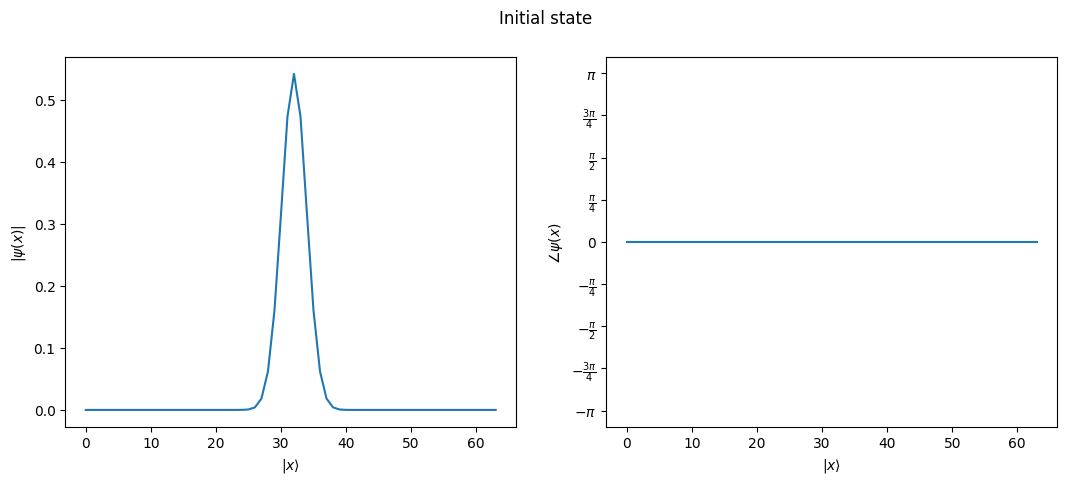

Plotting lens slice 1/100


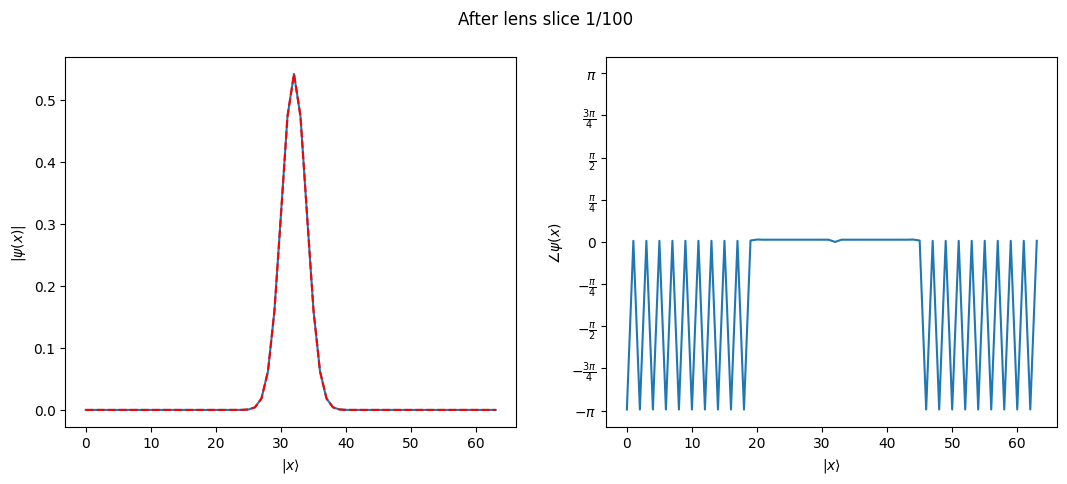

Plotting lens slice 21/100


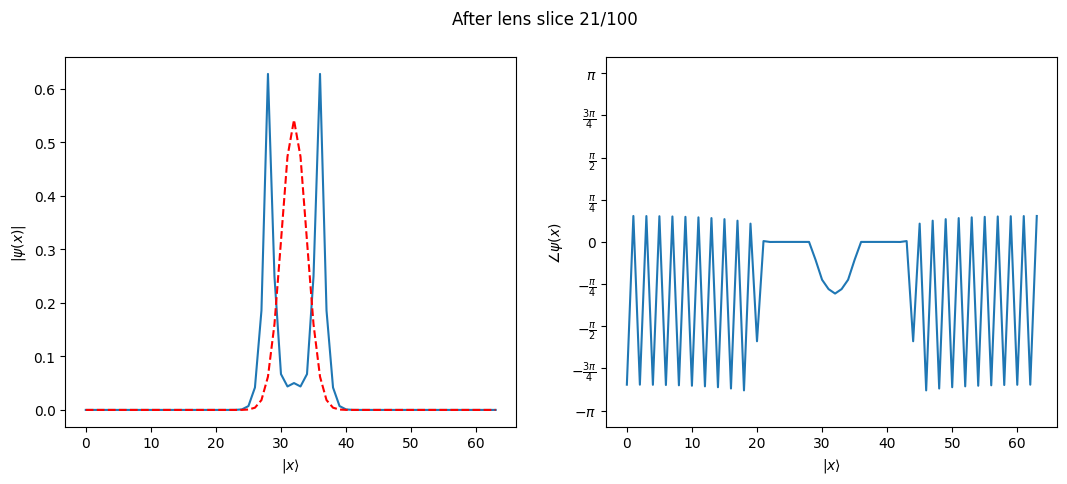

Plotting lens slice 41/100


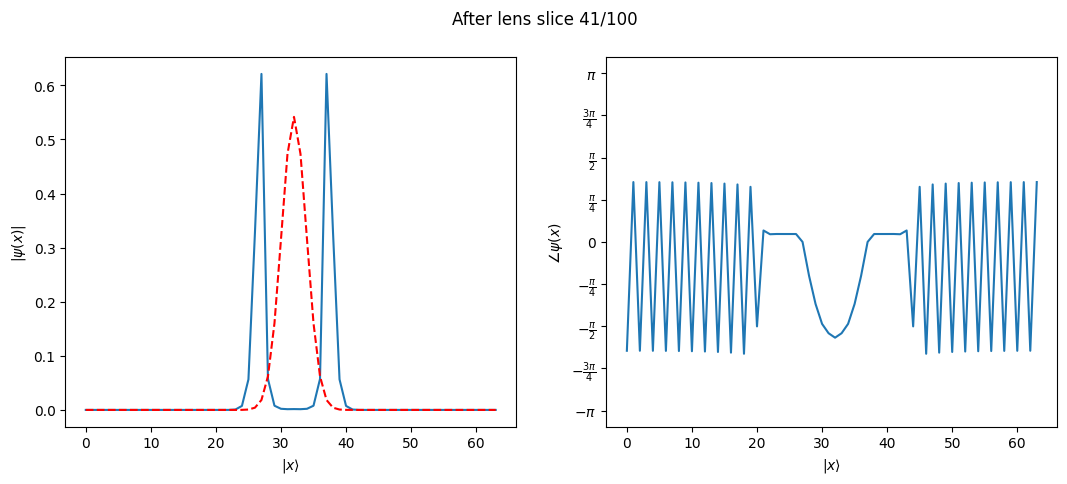

Plotting lens slice 61/100


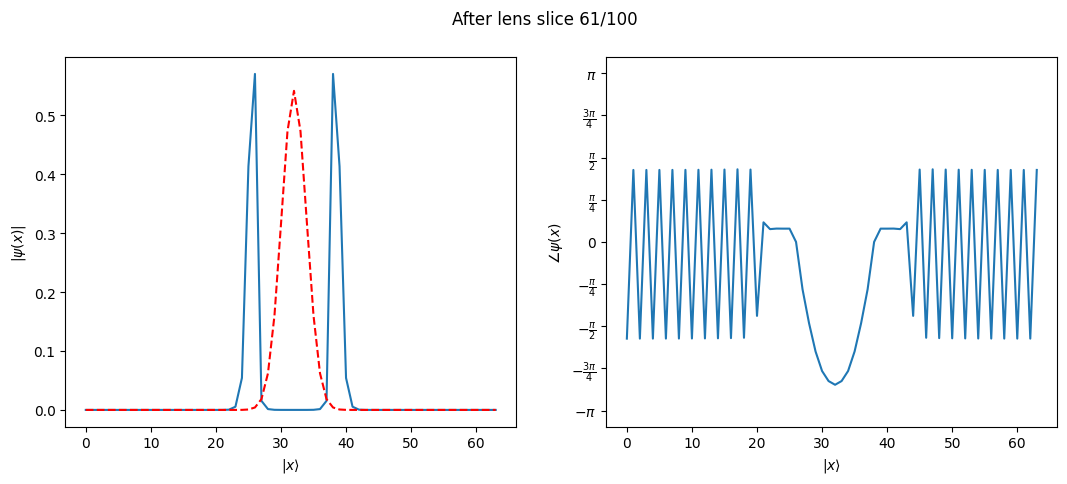

Plotting lens slice 81/100


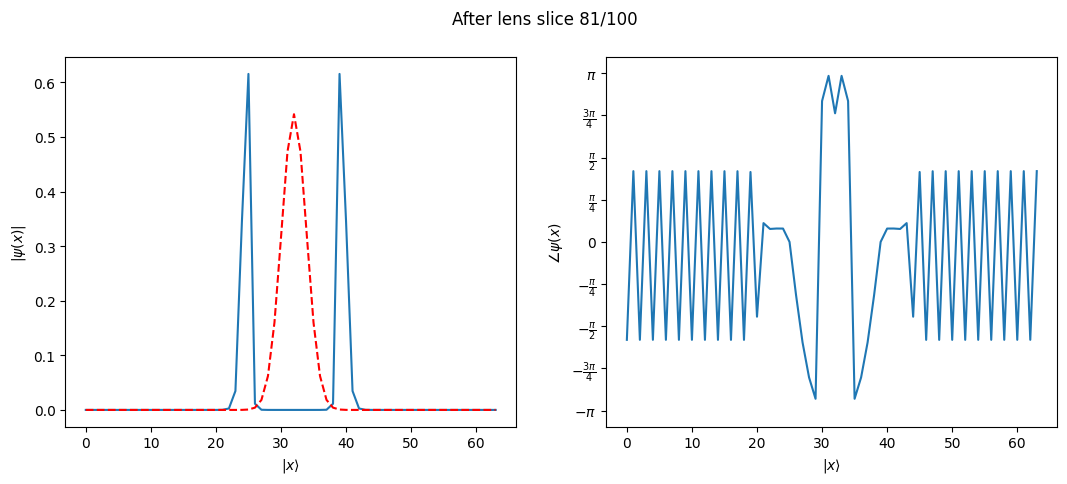

Plotting free space step 1/10


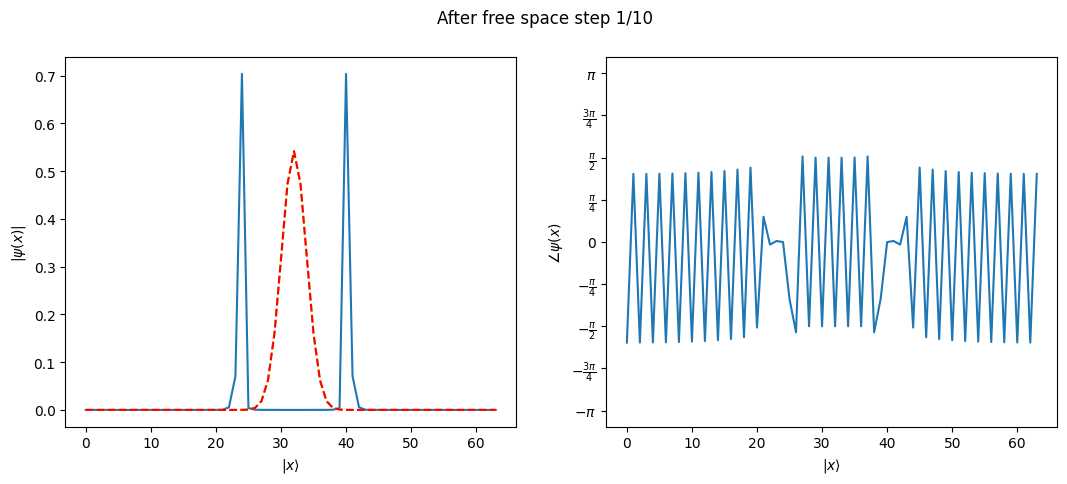

Plotting free space step 3/10


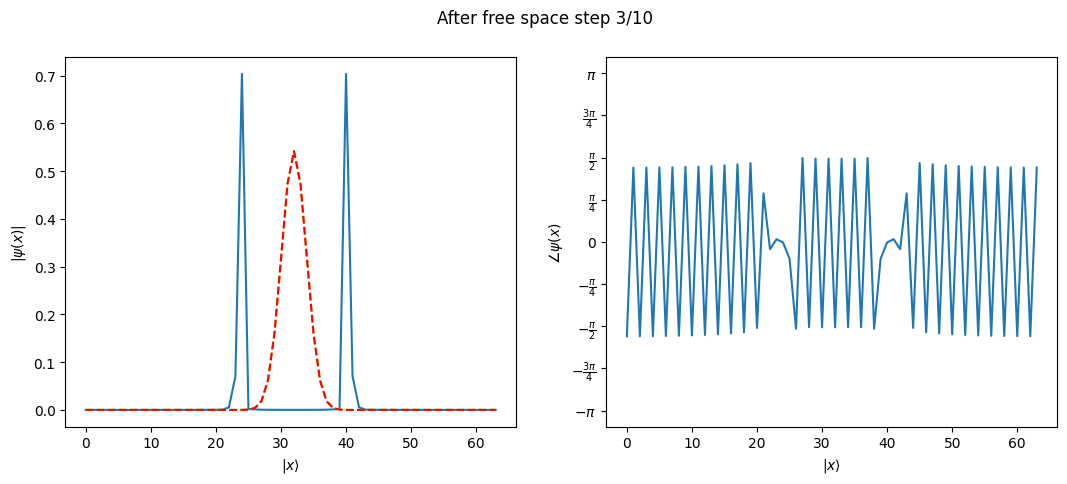

Plotting free space step 5/10


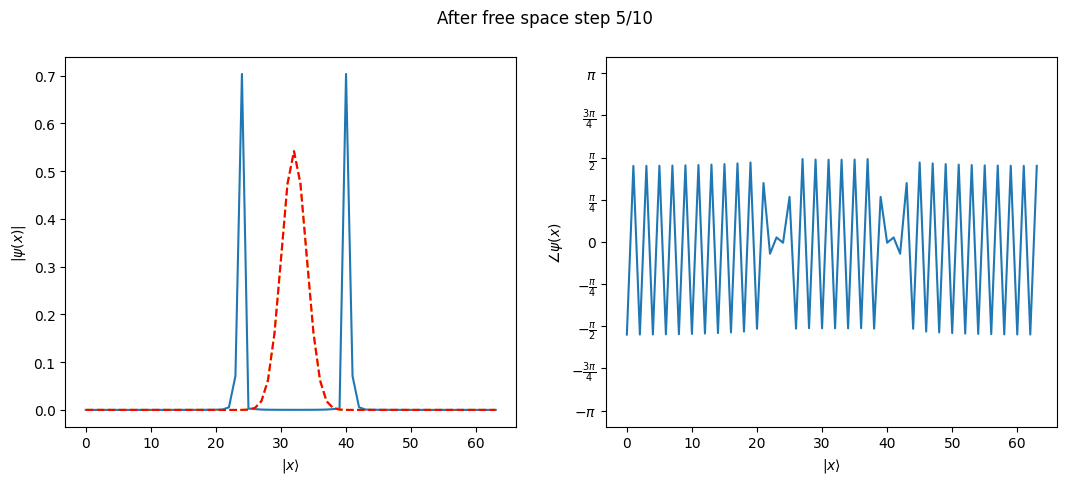

Plotting free space step 7/10


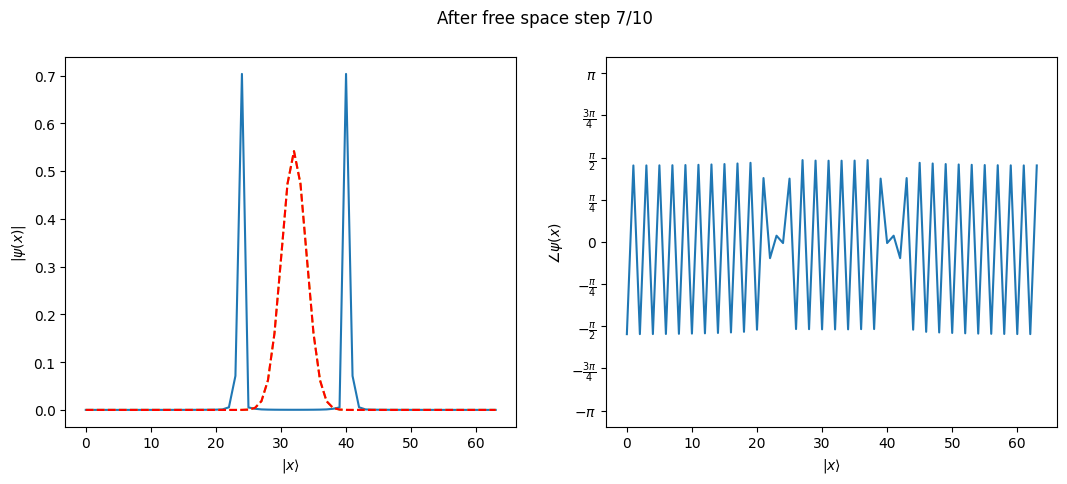

Plotting free space step 9/10


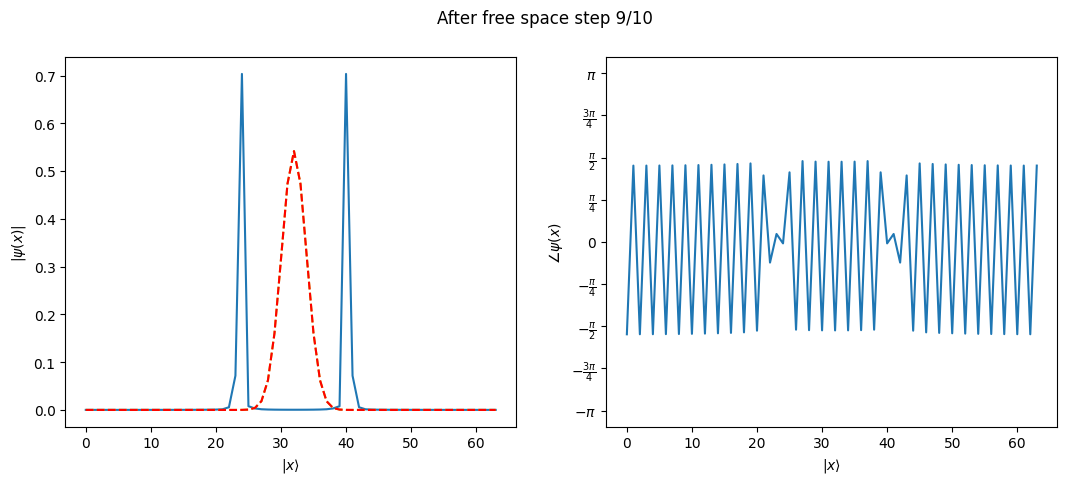

In [32]:
print("Plotting initial state")
plot_wavefunction(initial_statevector, plot_size_scale=1, normalize=True)
plt.suptitle("Initial state")
plt.show()

NUM_OF_LENS_SLICES_TO_PLOT = 5
NUM_OF_AFTER_LENS_SLICES_TO_PLOT = 5

for i, statevector in enumerate(lens_statevectors):
    if statevector is None:
        continue
    if (
        total_lenses_simulated > NUM_OF_LENS_SLICES_TO_PLOT
        and i % (total_lenses_simulated // NUM_OF_LENS_SLICES_TO_PLOT) != 0
    ):
        continue

    print(f"Plotting lens slice {i + 1}/{lens_slices}")

    fig, (ax1, ax2) = plot_wavefunction(statevector, plot_size_scale=1, normalize=True)

    z = lens_slice_thickness * (i + 1)
    R_z, w_z = propagated_gaussian_wavefront_hitting_lens(
        gaussian_beam_waist, z, focal_length, vacuum_wavelength, refractive_index
    )
    signal = gaussian_signal(x_axis, w_z, gaussian_mean)
    ax1.plot(np.abs(signal.normalized_data), "r--", label="thin lens analytical")

    plt.suptitle(f"After lens slice {i + 1}/{lens_slices}")
    plt.show()

for i, statevector in enumerate(after_lens_statevectors):
    if statevector is None:
        continue
    if i % (num_of_steps_after_lens // NUM_OF_AFTER_LENS_SLICES_TO_PLOT) != 0:
        continue

    print(f"Plotting free space step {i + 1}/{num_of_steps_after_lens}")
    fig, (ax1, ax2) = plot_wavefunction(statevector, plot_size_scale=1, normalize=True)

    z = step_size_after_lens * (i + 1) + lens_thickness
    R_z, w_z = free_space_propagated_gaussian_wavefront(
        gaussian_beam_waist, z, vacuum_wavelength, refractive_index=1.0
    )
    signal = gaussian_signal(x_axis, w_z, gaussian_mean)
    ax1.plot(np.abs(signal.normalized_data), "y--", label="free space analytical")

    R_z, w_z = propagated_gaussian_wavefront_hitting_lens(
        gaussian_beam_waist,
        z,
        focal_length,
        vacuum_wavelength,
        refractive_index,
    )
    signal = gaussian_signal(x_axis, w_z, gaussian_mean)
    ax1.plot(np.abs(signal.normalized_data), "r--", label="thin lens analytical")

    plt.suptitle(f"After free space step {i + 1}/{num_of_steps_after_lens}")
    plt.show()